In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import json
from methods import (
    CVXPYEstimator,
    FISTAEstimator, 
    ProximalGDEstimator,
    ProjectedGDEstimator
)

from methods import (
    ProximalNewtonEstimator,
    ProximalNewtonLBFGSEstimator,
    ProximalAdaGradEstimator
)

from utils import (
    TruncatedNormal,
    TruncatedGMM,
    Sinusoidal,
    StepFunction,
    
    plot_density,
)

from cross_validation import KFold_CV_LambdaSelector, CVSelectorMetric

/var/folders/8v/b1l_n51d2_b4pkp_5kxnxwhh0000gn/T/ipykernel_12765/1719426804.py:67: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  density_plot.show()
/var/folders/8v/b1l_n51d2_b4pkp_5kxnxwhh0000gn/T/ipykernel_12765/1719426804.py:90: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  density_plot.show()


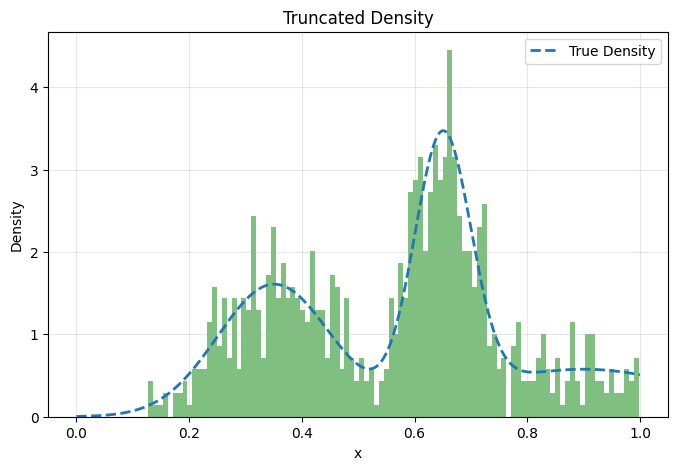

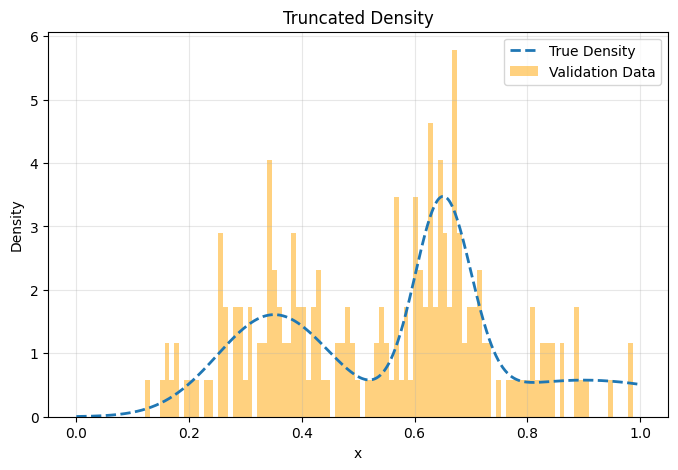

In [2]:
n_samples = 1000

sampler_params = {
    'components': [
        {'mean': 0.35, 'std': 0.1, 'lower': 0.0, 'upper': 1.0},
        {'mean': 0.65, 'std': 0.05, 'lower': 0.0, 'upper': 1.0},
        {'mean': 0.90, 'std': 0.2, 'lower': 0.0, 'upper': 1.0}
    ],
    'weights': [
        0.4,
        0.4,
        0.2
    ]
}
sampler = TruncatedGMM(
    **sampler_params,
)


# sampler_params = {
#     'mean': 0.35,
#     'std': 0.1,
# }

# sampler = TruncatedNormal(
#     **sampler_params,
# )


sampler_setup = {
    "sampler": sampler.__class__.__name__,
    "sampler_params": sampler_params,
    "n_samples": n_samples
}



data_all = pd.DataFrame({
    'W1': np.concatenate([
        sampler.generate_samples(n_samples)
    ])
})

# cut data into training and validation sets
data = data_all[:4 * n_samples // 5]
data_val = data_all[4 * n_samples // 5:]

# plot the density of the data and the true density
density_plot = plot_density(
    grid_points=np.linspace(0, 1, 1000),
    true_density=sampler.compute_density(
        np.linspace(0, 1, 1000)
    ),
    title="Truncated Density",
    method_label="True Density",
    show=False
)
ax = density_plot.gca()
ax.hist(
    data["W1"], 
    bins=100, 
    density=True, 
    alpha=0.5, 
    label="Sampled Data",
    color="green"
)
density_plot.show()

# plot the density of the data
density_plot = plot_density(
    grid_points=np.linspace(0, 1, 1000),
    true_density=sampler.compute_density(
        np.linspace(0, 1, 1000)
    ),
    title="Truncated Density",
    method_label="True Density",
    show=False
)
ax = density_plot.gca()
# show validation data
ax.hist(
    data_val["W1"], 
    bins=100, 
    density=True, 
    alpha=0.5, 
    label="Validation Data",
    color="orange"
)
ax.legend()
density_plot.show()



Evaluating lambda: 1000 (Index 1/4)


Processing fold 1/3 for lambda=1000
Iteration 0: logZ=0.000000
Iter   0: obj=0.000000, change=0.00e+00, α=0.000, ‖θ[1:]‖₁=0.000, h_range=[2.57e+00, 1.29e+01], num_knots=0
Converged at iter 0 (parameter change)
Results - number of selected knots: 0


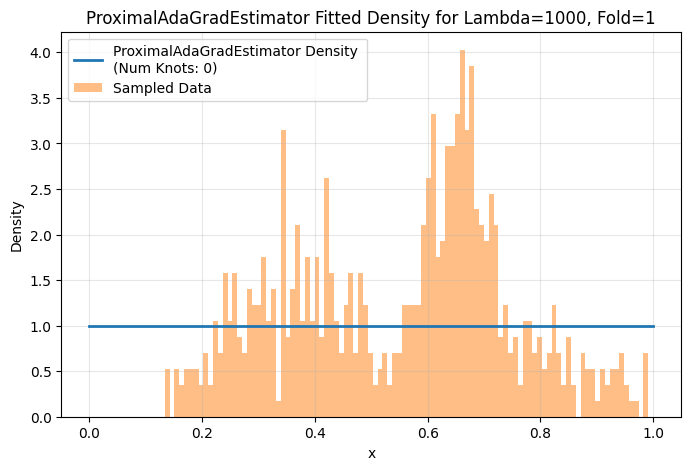

Fold 1 - SLL: -0.0050, BIC: 9.1428
Results - number of selected knots: 0
Processing fold 2/3 for lambda=1000
Iteration 0: logZ=0.000000
Iter   0: obj=0.000000, change=0.00e+00, α=0.000, ‖θ[1:]‖₁=0.000, h_range=[1.00e-02, 1.29e+01], num_knots=0
Converged at iter 0 (parameter change)
Results - number of selected knots: 0


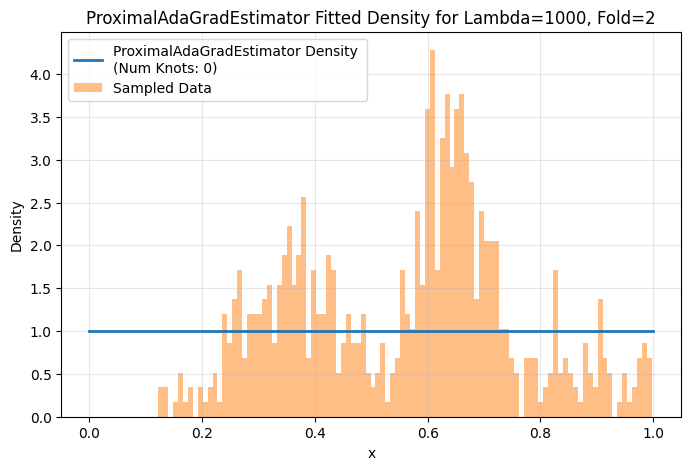

Fold 2 - SLL: -0.0050, BIC: 9.1298
Results - number of selected knots: 0
Processing fold 3/3 for lambda=1000
Iteration 0: logZ=0.000000
Iter   0: obj=0.000000, change=0.00e+00, α=0.000, ‖θ[1:]‖₁=0.000, h_range=[1.00e-02, 1.29e+01], num_knots=0
Converged at iter 0 (parameter change)
Results - number of selected knots: 0


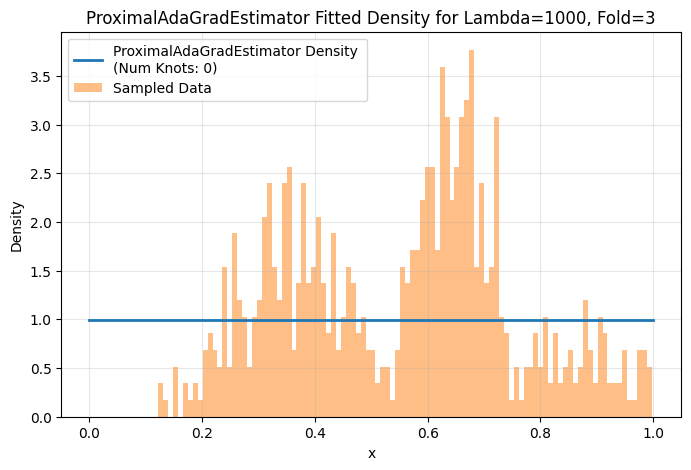

Fold 3 - SLL: -0.0050, BIC: 9.1298
Results - number of selected knots: 0


Evaluating lambda: 100 (Index 2/4)


Processing fold 1/3 for lambda=100
Iteration 0: logZ=0.000578
Iter   0: obj=0.000000, change=5.78e-04, α=0.000, ‖θ[1:]‖₁=0.001, h_range=[2.57e+00, 1.29e+01], num_knots=81
Iteration 1000: logZ=0.000022
Iter 1000: obj=-1.818242, change=2.21e-05, α=0.000, ‖θ[1:]‖₁=0.160, h_range=[2.62e+00, 1.29e+01], num_knots=72
Iteration 2000: logZ=0.000008
Iter 2000: obj=-2.027093, change=8.20e-06, α=0.000, ‖θ[1:]‖₁=0.176, h_range=[2.63e+00, 1.29e+01], num_knots=53
Converged at iter 2592 (parameter change)
Results - number of selected knots: 48


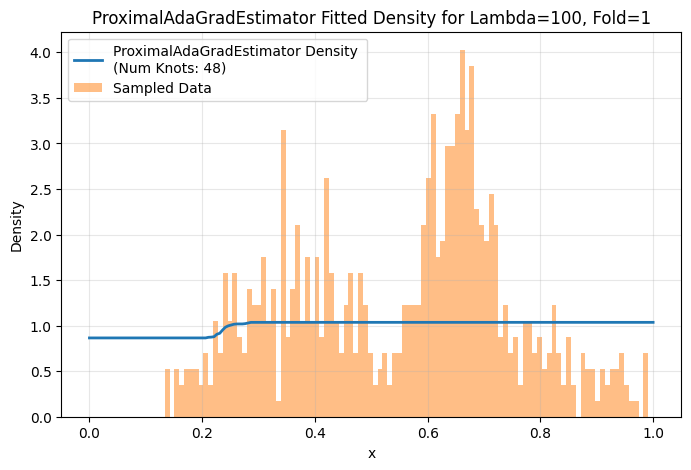

Fold 1 - SLL: 0.0304, BIC: 264.4327
Results - number of selected knots: 48
Processing fold 2/3 for lambda=100
Iteration 0: logZ=0.001052
Iter   0: obj=0.000000, change=1.05e-03, α=0.000, ‖θ[1:]‖₁=0.001, h_range=[1.00e-02, 1.29e+01], num_knots=115
Iteration 1000: logZ=0.000032
Iter 1000: obj=-4.997471, change=3.18e-05, α=0.000, ‖θ[1:]‖₁=0.274, h_range=[1.00e-08, 1.29e+01], num_knots=85
Iteration 2000: logZ=0.000012
Iter 2000: obj=-5.389027, change=1.21e-05, α=0.000, ‖θ[1:]‖₁=0.296, h_range=[1.00e-08, 1.29e+01], num_knots=63
Iteration 3000: logZ=0.000008
Iter 3000: obj=-5.587121, change=8.28e-06, α=0.000, ‖θ[1:]‖₁=0.306, h_range=[1.00e-08, 1.29e+01], num_knots=52
Converged at iter 3265 (parameter change)
Results - number of selected knots: 52


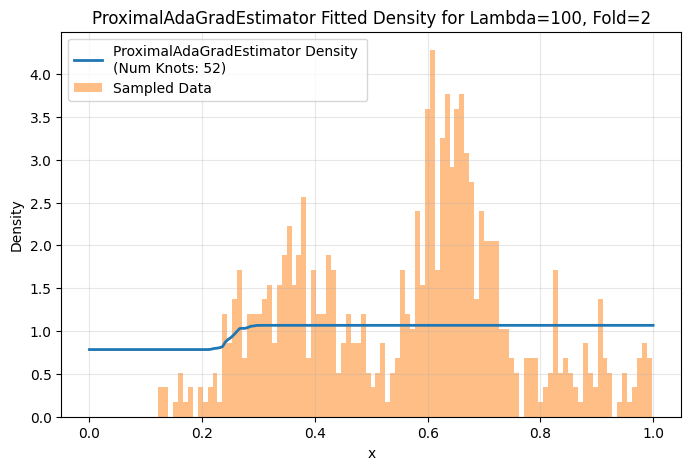

Fold 2 - SLL: 0.0386, BIC: 282.1038
Results - number of selected knots: 52
Processing fold 3/3 for lambda=100
Iteration 0: logZ=0.000794
Iter   0: obj=0.000000, change=7.94e-04, α=0.000, ‖θ[1:]‖₁=0.001, h_range=[1.00e-02, 1.29e+01], num_knots=94
Iteration 1000: logZ=0.000022
Iter 1000: obj=-3.207056, change=2.25e-05, α=0.000, ‖θ[1:]‖₁=0.227, h_range=[1.00e-08, 1.29e+01], num_knots=80
Iteration 2000: logZ=0.000007
Iter 2000: obj=-3.425424, change=6.80e-06, α=0.000, ‖θ[1:]‖₁=0.241, h_range=[1.00e-08, 1.29e+01], num_knots=67
Converged at iter 2700 (parameter change)
Results - number of selected knots: 58


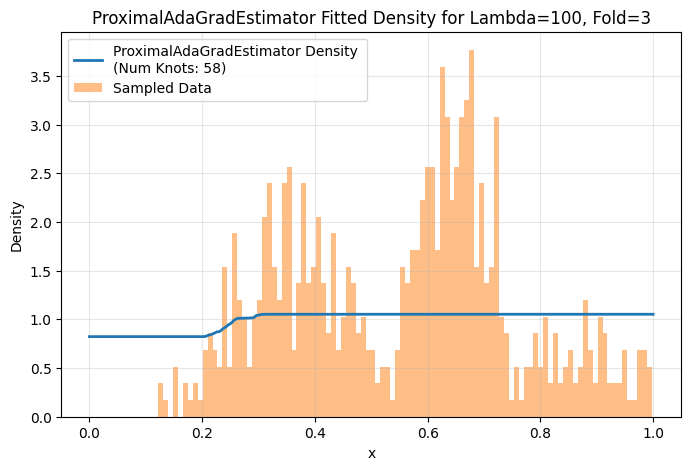

Fold 3 - SLL: 0.0368, BIC: 318.2026
Results - number of selected knots: 58


Evaluating lambda: 10 (Index 3/4)


Processing fold 1/3 for lambda=10
Iteration 0: logZ=0.006828
Iter   0: obj=0.000000, change=6.83e-03, α=0.000, ‖θ[1:]‖₁=0.017, h_range=[2.57e+00, 1.29e+01], num_knots=601
Iteration 1000: logZ=0.000328
Iter 1000: obj=-145.089289, change=3.28e-04, α=0.000, ‖θ[1:]‖₁=3.885, h_range=[1.83e+00, 1.29e+01], num_knots=537
Iteration 2000: logZ=0.000158
Iter 2000: obj=-152.678021, change=1.58e-04, α=0.000, ‖θ[1:]‖₁=4.375, h_range=[1.81e+00, 1.29e+01], num_knots=486
Iteration 3000: logZ=0.000103
Iter 3000: obj=-155.986385, change=1.03e-04, α=0.000, ‖θ[1:]‖₁=4.586, h_range=[1.82e+00, 1.29e+01], num_knots=438
Iteration 4000: logZ=0.000075
Iter 4000: obj=-157.998803, change=7.53e-05, α=0.000, ‖θ[1:]‖₁=4.717, h_range=[1.82e+00, 1.29e+01], num_knots=414
Iteration 5000: logZ=0.000057
Iter 5000: obj=-159.398112, change=5.65e-05, α=0.000, ‖θ[1:]‖₁=4.811, h_range=[1.82e+00, 1.29e+01], num_knots=

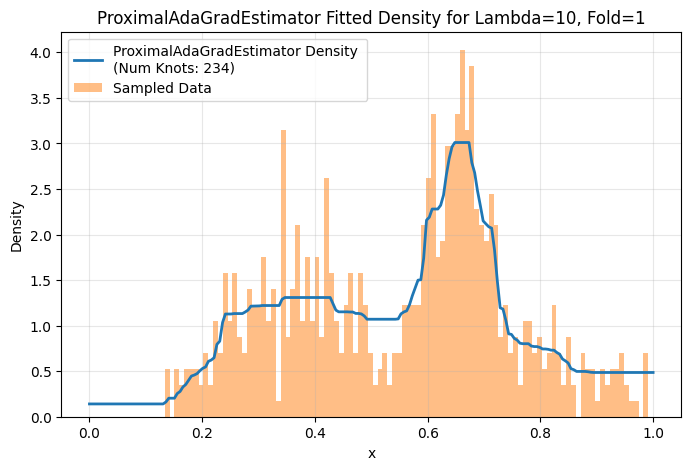

Fold 1 - SLL: 0.3172, BIC: 1153.7166
Results - number of selected knots: 234
Processing fold 2/3 for lambda=10
Iteration 0: logZ=0.007531
Iter   0: obj=0.000000, change=7.53e-03, α=0.000, ‖θ[1:]‖₁=0.018, h_range=[1.00e-02, 1.29e+01], num_knots=587
Iteration 1000: logZ=0.000335
Iter 1000: obj=-165.970213, change=3.35e-04, α=0.000, ‖θ[1:]‖₁=4.026, h_range=[1.00e-08, 1.29e+01], num_knots=552
Iteration 2000: logZ=0.000164
Iter 2000: obj=-176.098816, change=1.64e-04, α=0.000, ‖θ[1:]‖₁=4.629, h_range=[1.00e-08, 1.29e+01], num_knots=477
Iteration 3000: logZ=0.000102
Iter 3000: obj=-180.323026, change=1.02e-04, α=0.000, ‖θ[1:]‖₁=4.886, h_range=[1.00e-08, 1.29e+01], num_knots=430
Iteration 4000: logZ=0.000074
Iter 4000: obj=-182.831626, change=7.40e-05, α=0.000, ‖θ[1:]‖₁=5.024, h_range=[1.00e-08, 1.29e+01], num_knots=401
Iteration 5000: logZ=0.000056
Iter 5000: obj=-184.588170, change=5.58e-05, α=0.000, ‖θ[1:]‖₁=5.116, h_range=[1.00e-08, 1.29e+01], num_knots=375
Iteration 6000: logZ=0.000043
It

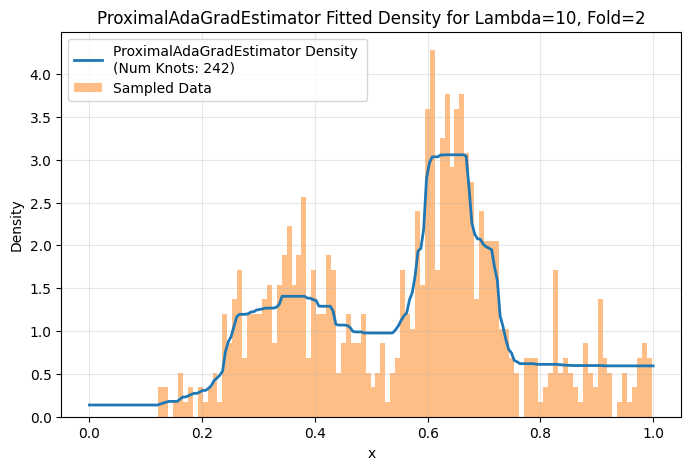

Fold 2 - SLL: 0.2450, BIC: 1248.1954
Results - number of selected knots: 242
Processing fold 3/3 for lambda=10
Iteration 0: logZ=0.006846
Iter   0: obj=0.000000, change=6.85e-03, α=0.000, ‖θ[1:]‖₁=0.016, h_range=[1.00e-02, 1.29e+01], num_knots=584
Iteration 1000: logZ=0.000341
Iter 1000: obj=-141.631063, change=3.41e-04, α=0.000, ‖θ[1:]‖₁=3.670, h_range=[1.00e-08, 1.29e+01], num_knots=545
Iteration 2000: logZ=0.000173
Iter 2000: obj=-151.192447, change=1.73e-04, α=0.000, ‖θ[1:]‖₁=4.320, h_range=[1.00e-08, 1.29e+01], num_knots=460
Iteration 3000: logZ=0.000098
Iter 3000: obj=-155.017380, change=9.76e-05, α=0.000, ‖θ[1:]‖₁=4.587, h_range=[1.00e-08, 1.29e+01], num_knots=424
Iteration 4000: logZ=0.000072
Iter 4000: obj=-157.502975, change=7.16e-05, α=0.000, ‖θ[1:]‖₁=4.723, h_range=[1.00e-08, 1.29e+01], num_knots=401
Iteration 5000: logZ=0.000058
Iter 5000: obj=-159.264962, change=5.78e-05, α=0.000, ‖θ[1:]‖₁=4.820, h_range=[1.00e-08, 1.29e+01], num_knots=371
Iteration 6000: logZ=0.000044
It

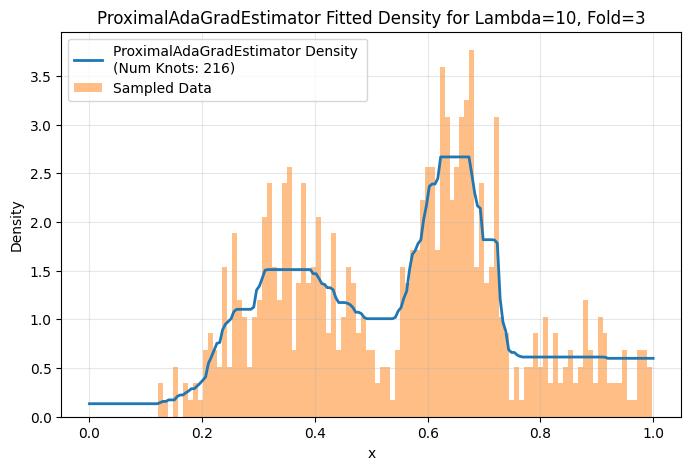

Fold 3 - SLL: 0.3309, BIC: 1039.9807
Results - number of selected knots: 216


Evaluating lambda: 1 (Index 4/4)


Processing fold 1/3 for lambda=1
Iteration 0: logZ=0.007513
Iter   0: obj=0.000000, change=7.51e-03, α=0.000, ‖θ[1:]‖₁=0.019, h_range=[2.57e+00, 1.29e+01], num_knots=630
Iteration 1000: logZ=0.000441
Iter 1000: obj=-191.142691, change=4.41e-04, α=0.000, ‖θ[1:]‖₁=5.101, h_range=[1.61e+00, 1.29e+01], num_knots=664
Iteration 2000: logZ=0.000247
Iter 2000: obj=-203.629619, change=2.47e-04, α=0.000, ‖θ[1:]‖₁=6.254, h_range=[1.53e+00, 1.29e+01], num_knots=660
Iteration 3000: logZ=0.000161
Iter 3000: obj=-209.563335, change=1.61e-04, α=0.000, ‖θ[1:]‖₁=6.787, h_range=[1.51e+00, 1.29e+01], num_knots=658
Iteration 4000: logZ=0.000122
Iter 4000: obj=-213.774156, change=1.22e-04, α=0.000, ‖θ[1:]‖₁=7.211, h_range=[1.50e+00, 1.29e+01], num_knots=652
Iteration 5000: logZ=0.000100
Iter 5000: obj=-217.059814, change=1.00e-04, α=0.000, ‖θ[1:]‖₁=7.623, h_range=[1.49e+00, 1.29e+01], num_knots=

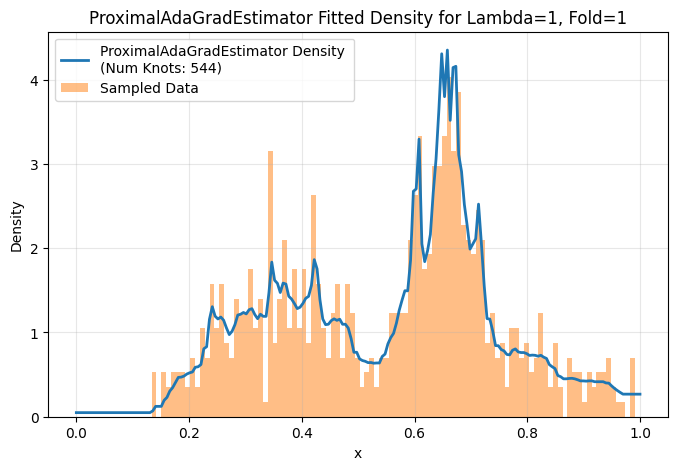

Fold 1 - SLL: 0.3220, BIC: 2951.9478
Results - number of selected knots: 544
Processing fold 2/3 for lambda=1
Iteration 0: logZ=0.008188
Iter   0: obj=0.000000, change=8.19e-03, α=0.000, ‖θ[1:]‖₁=0.020, h_range=[1.00e-02, 1.29e+01], num_knots=621
Iteration 1000: logZ=0.000463
Iter 1000: obj=-213.318734, change=4.63e-04, α=0.000, ‖θ[1:]‖₁=5.213, h_range=[1.00e-08, 1.29e+01], num_knots=663
Iteration 2000: logZ=0.000269
Iter 2000: obj=-229.649842, change=2.69e-04, α=0.000, ‖θ[1:]‖₁=6.482, h_range=[1.00e-08, 1.29e+01], num_knots=659
Iteration 3000: logZ=0.000171
Iter 3000: obj=-236.994533, change=1.71e-04, α=0.000, ‖θ[1:]‖₁=7.163, h_range=[1.00e-08, 1.29e+01], num_knots=654
Iteration 4000: logZ=0.000126
Iter 4000: obj=-242.033639, change=1.26e-04, α=0.000, ‖θ[1:]‖₁=7.705, h_range=[1.00e-08, 1.29e+01], num_knots=648
Iteration 5000: logZ=0.000104
Iter 5000: obj=-245.977372, change=1.04e-04, α=0.000, ‖θ[1:]‖₁=8.195, h_range=[1.00e-08, 1.29e+01], num_knots=644
Iteration 6000: logZ=0.000087
Ite

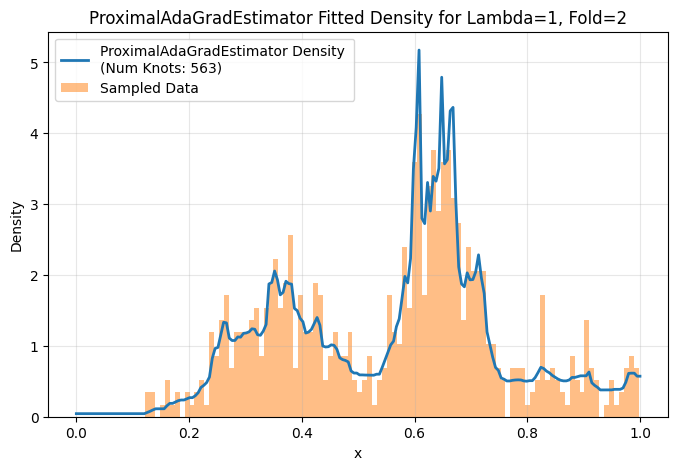

Fold 2 - SLL: 0.2321, BIC: 3121.1865
Results - number of selected knots: 563
Processing fold 3/3 for lambda=1
Iteration 0: logZ=0.007527
Iter   0: obj=0.000000, change=7.53e-03, α=0.000, ‖θ[1:]‖₁=0.018, h_range=[1.00e-02, 1.29e+01], num_knots=623
Iteration 1000: logZ=0.000487
Iter 1000: obj=-186.524862, change=4.87e-04, α=0.000, ‖θ[1:]‖₁=4.923, h_range=[1.00e-08, 1.29e+01], num_knots=666
Iteration 2000: logZ=0.000264
Iter 2000: obj=-201.572611, change=2.64e-04, α=0.000, ‖θ[1:]‖₁=6.145, h_range=[1.00e-08, 1.29e+01], num_knots=659
Iteration 3000: logZ=0.000165
Iter 3000: obj=-208.189989, change=1.65e-04, α=0.000, ‖θ[1:]‖₁=6.748, h_range=[1.00e-08, 1.29e+01], num_knots=659
Iteration 4000: logZ=0.000121
Iter 4000: obj=-212.845673, change=1.21e-04, α=0.000, ‖θ[1:]‖₁=7.211, h_range=[1.00e-08, 1.29e+01], num_knots=656
Iteration 5000: logZ=0.000099
Iter 5000: obj=-216.529041, change=9.90e-05, α=0.000, ‖θ[1:]‖₁=7.650, h_range=[1.00e-08, 1.29e+01], num_knots=651
Iteration 6000: logZ=0.000086
Ite

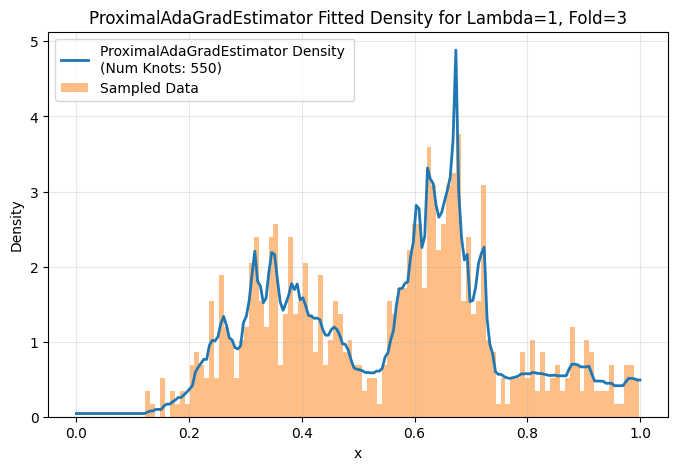

Fold 3 - SLL: 0.3319, BIC: 2979.2422
Results - number of selected knots: 550

Best lambda: 10 with average SLL: 0.2977
Best lambda: 10


In [3]:
lam_selector = KFold_CV_LambdaSelector(
    method=ProximalAdaGradEstimator,
    full_data=data_all,
    folds=3,
    tolerance=5e-6,
    max_iter=30001,
    n_grid_points=200,
    lambdas=np.array([
        # 0.001, 
        # 0.1, 
        1, 
        10, 
        100, 
        1000,
    ]),
    log_frequency=1000,
    basis_order=0,
    alpha=0.000005,
    metric=CVSelectorMetric.SLL,
    do_warm_start=False,
)

# Select the best lambda using cross-validation
best_lambda = lam_selector.select_lambda(do_plot_fited=True)

print(f"Best lambda: {best_lambda}")

In [4]:
summary = lam_selector.get_cv_results_summary()
print(json.dumps(summary, indent=2))

{
  "1000.0": {
    "avg_sll": -0.0049875415110389384,
    "avg_bic": 9.134169665005155,
    "avg_n_selected_knots": 0.0,
    "n_valid_folds_sll": 3,
    "n_valid_folds_bic": 3
  },
  "100.0": {
    "avg_sll": 0.03526423644932306,
    "avg_bic": 288.24636836869075,
    "avg_n_selected_knots": 52.666666666666664,
    "n_valid_folds_sll": 3,
    "n_valid_folds_bic": 3
  },
  "10.0": {
    "avg_sll": 0.2977160185719118,
    "avg_bic": 1147.2975459596028,
    "avg_n_selected_knots": 230.66666666666666,
    "n_valid_folds_sll": 3,
    "n_valid_folds_bic": 3
  },
  "1.0": {
    "avg_sll": 0.29536044675675427,
    "avg_bic": 3017.4588202740197,
    "avg_n_selected_knots": 552.3333333333334,
    "n_valid_folds_sll": 3,
    "n_valid_folds_bic": 3
  }
}


In [5]:
best_lambda 

10